In [29]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from pathlib import Path


In [31]:
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
DATA_DIR = ROOT / "data"
TRAIN_PATH = DATA_DIR / "processed" / "train.parquet"

In [2]:
prices = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("price"))
    .collect()
    .pivot(values="value", index="day_utc", on="metric")
    .sort("day_utc")
    .to_pandas()
    .set_index("day_utc")
    .apply(pd.to_numeric, errors="coerce")
)

In [34]:
zero_var_cols = pd.read_csv(DATA_DIR / "common_zero_var_cols.csv")["metric"].tolist()
prices = prices.drop(columns=zero_var_cols, errors="ignore")

In [60]:
len(prices.columns)

6045

In [35]:
prices = prices.dropna(axis=1, thresh=int(0.5 * len(prices)))
prices = prices.fillna(prices.median())
prices = prices.loc[:, prices.nunique() > 1]

print(f"Shape after cleaning: {prices.shape}")


corr = prices.corr(method="pearson")

Shape after cleaning: (5471, 6045)


In [54]:
dist = squareform(1 - corr.abs(), checks=False)
Z = linkage(dist, method="ward")

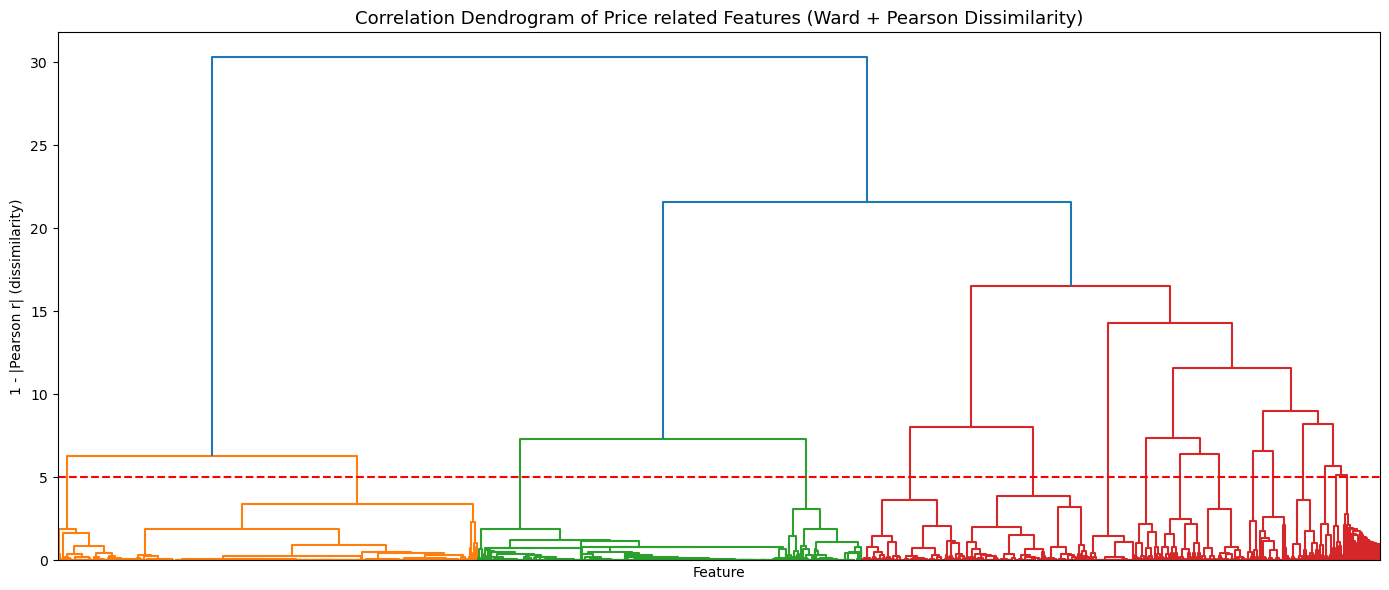

In [37]:
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, no_labels=True, ax=ax)
ax.set_title("Correlation Dendrogram of Price related Features (Ward + Pearson Dissimilarity)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
plt.axhline(y=5, color="red", linestyle="--", label="Dissimilarity Threshold (0.5)")
plt.tight_layout()
plt.show()

In [55]:
from scipy.cluster.hierarchy import fcluster

clusters_price = fcluster(Z, t=15, criterion="maxclust")

cluster_map_price = dict(zip(prices.columns, clusters_price))


cluster_df_price = pd.DataFrame({
    "feature": prices.columns,
    "cluster": clusters_price
})
cluster_df_price.head()

,feature,cluster
0,price_111d_sma,2
1,price_111d_sma_ratio,7
2,price_111d_sma_ratio_0sd_usd,2
3,price_111d_sma_ratio_0sd_usd_sats,7
4,price_111d_sma_ratio_1m_sma,11


In [52]:
cluster_df_price.value_counts("cluster")

cluster
2     1556
3     1411
6      567
5      480
1      365
4      342
15     217
10     202
7      200
9      186
12     143
13     128
8      124
11      64
14      60
Name: count, dtype: int64

In [ ]:
cluster_df_price.sort_values("cluster")

In [40]:
zoom_cols = cluster_df_price[cluster_df_price["cluster"] == 14]["feature"].tolist()
zoom_cols

['price_12d_ema_ratio_pct1',
 'price_12d_ema_ratio_pct2',
 'price_12d_ema_ratio_pct5',
 'price_13d_ema_ratio_pct1',
 'price_13d_ema_ratio_pct2',
 'price_13d_ema_ratio_pct5',
 'price_13d_sma_ratio_pct1',
 'price_13d_sma_ratio_pct2',
 'price_13d_sma_ratio_pct5',
 'price_1m_ema_ratio_1y_m3sd_usd_sats',
 'price_1m_ema_ratio_4y_m3sd_usd_sats',
 'price_1m_ema_ratio_m3sd_usd_sats',
 'price_1m_ema_ratio_pct1',
 'price_1m_ema_ratio_pct2',
 'price_1m_ema_ratio_pct5',
 'price_1m_sma_ratio_1y_m2_5sd_usd_sats',
 'price_1m_sma_ratio_4y_m3sd_usd_sats',
 'price_1m_sma_ratio_m3sd_usd_sats',
 'price_1m_sma_ratio_pct1',
 'price_1m_sma_ratio_pct2',
 'price_1m_sma_ratio_pct5',
 'price_1w_ema_ratio_pct1',
 'price_1w_ema_ratio_pct2',
 'price_1w_ema_ratio_pct5',
 'price_1w_sma_ratio_pct1',
 'price_1w_sma_ratio_pct2',
 'price_1w_sma_ratio_pct5',
 'price_21d_ema_ratio_pct1',
 'price_21d_ema_ratio_pct2',
 'price_21d_ema_ratio_pct5',
 'price_21d_sma_ratio_1y_m3sd_usd_sats',
 'price_21d_sma_ratio_pct1',
 'price_21

/var/folders/8t/x329s8055vdgtxtnhtz6vkzr0000gn/T/ipykernel_60908/2117890444.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


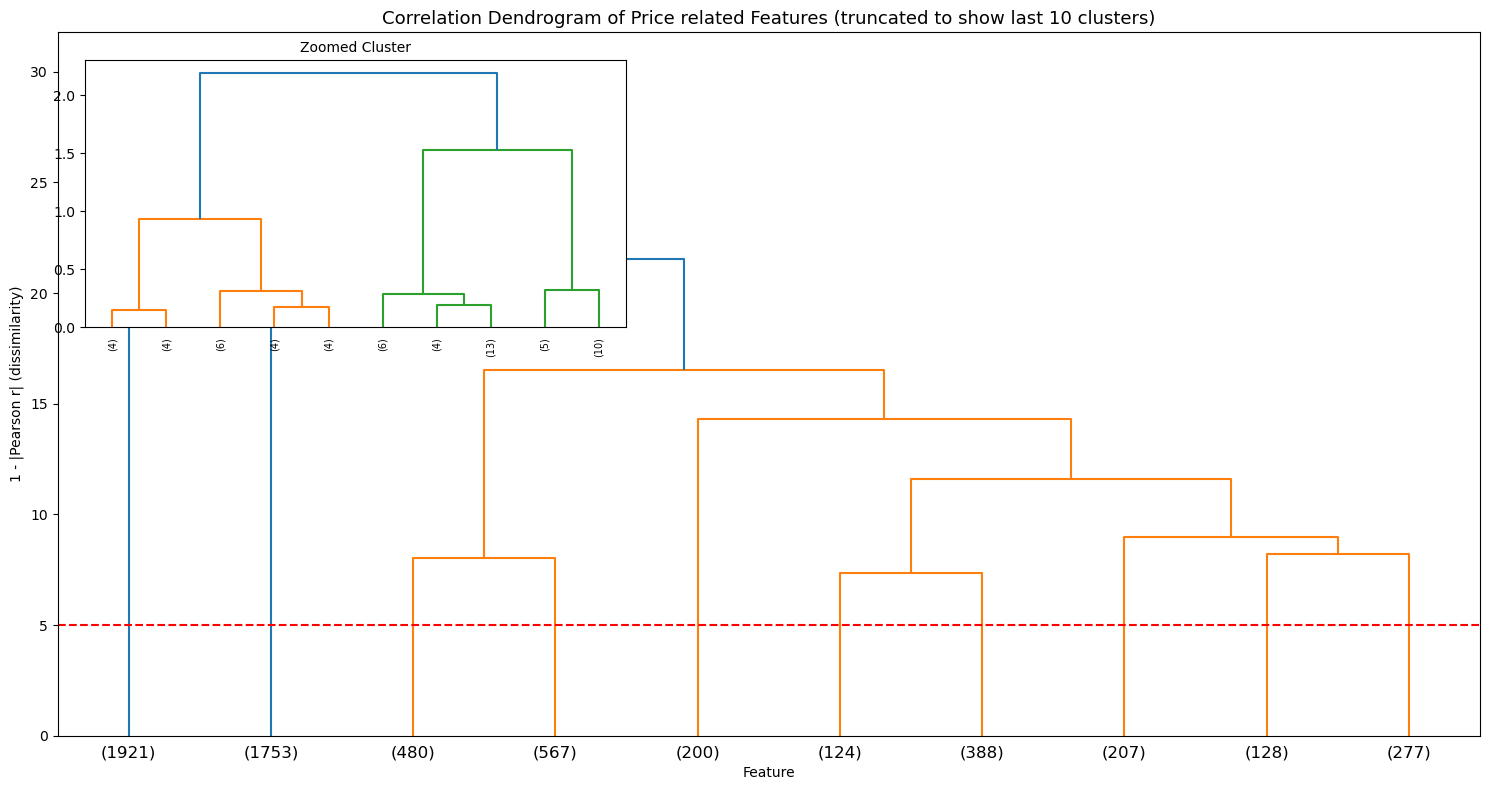

In [49]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(15, 8))
dendrogram(Z, truncate_mode='lastp', p=10,labels=prices.columns, ax=ax)
ax.set_title("Correlation Dendrogram of Price related Features (truncated to show last 10 clusters)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
plt.axhline(y=5, color="red", linestyle="--")

# -----------------------------
# 2. Inset dendrogram
# -----------------------------
zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = 1 - zoom_corr

Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

axins = inset_axes(
    ax,
    width="38%",
    height="38%",
    loc="upper left",
    borderpad=2
)

dendrogram(
    Z_zoom,
    truncate_mode='lastp', p=10,
    labels=zoom_cols,
    ax=axins,
    leaf_rotation=90,
    leaf_font_size=7
)

axins.set_title("Zoomed Cluster", fontsize=10)
axins.set_ylabel("")
axins.set_xlabel("")

plt.tight_layout()
plt.show()

In [56]:
ddata = dendrogram(

    Z,

    truncate_mode="lastp",

    p=10,

    no_plot=True

)

shown_nodes = ddata["leaves"]

shown_nodes

[12076, 12079, 12072, 12073, 12032, 12061, 12077, 12078, 12071, 12075]

In [62]:
zdata = dendrogram(
    Z_zoom,
    truncate_mode="lastp",
    p=10,
    no_plot=True
)

shown_nodes_zoom = zdata["leaves"]
shown_nodes_zoom

[1914, 3812, 3818, 1915, 3811, 1385, 3830, 3831, 3312, 3823]

In [57]:
n = len(prices.columns)

def get_cluster_members(node_id, Z, labels):
    """
    Given a dendrogram node ID, return original feature names inside it.
    """
    if node_id < n:
        return [labels[node_id]]
    
    row = int(node_id - n)
    left = int(Z[row, 0])
    right = int(Z[row, 1])
    
    return (
        get_cluster_members(left, Z, labels)
        + get_cluster_members(right, Z, labels)
    )

In [58]:
last10_clusters = []

for i, node in enumerate(shown_nodes, start=1):
    members = get_cluster_members(node, Z, list(prices.columns))
    
    last10_clusters.append({
        "display_cluster": i,
        "node_id": node,
        "n_features": len(members),
        "features": members
    })

last10_df = pd.DataFrame(last10_clusters)

last10_df

,display_cluster,node_id,n_features,features
0,1,12076,1921,"[price_5y_ago, price_2y_sma_ratio_1y_m1sd_usd,..."
1,2,12079,1753,"[price_2y_sma_ratio_2y_m2_5sd, price_2y_sma_ra..."
2,3,12072,480,"[price_21d_ema_ratio_1y_p2sd, price_12d_ema_ra..."
3,4,12073,567,"[price_55d_ema_ratio_pct5, price_55d_ema_ratio..."
4,5,12032,200,"[price_1w_sma_ratio, price_8d_sma_ratio, price..."
5,6,12061,124,"[price_55d_ema_ratio_1y_m1sd, price_55d_sma_ra..."
6,7,12077,388,"[price_1m_sma_ratio_2y_m2_5sd, price_34d_sma_r..."
7,8,12078,207,"[price_55d_ema_ratio_1w_sma, price_89d_ema_rat..."
8,9,12071,128,"[price_21d_sma_ratio_1y_zscore, price_1m_sma_r..."
9,10,12075,277,"[price_8d_sma_ratio_pct5, price_1w_sma_ratio_p..."


In [59]:
for row in last10_clusters:
    print(f"\nCluster {row['display_cluster']} | {row['n_features']} features")
    print(row["features"])


Cluster 1 | 1921 features
['price_5y_ago', 'price_2y_sma_ratio_1y_m1sd_usd', 'price_200w_ema_ratio_1y_m1sd_usd', 'price_4y_ema_ratio_1y_m1sd_usd', 'price_1y_ema_ratio_1y_m2sd_usd', 'price_2y_ema_ratio_1y_m1_5sd_usd', 'price_6y_ago', 'price_2y_sma_ratio_2y_m1sd_usd', 'price_200w_ema_ratio_2y_m1sd_usd', 'price_4y_ema_ratio_2y_m1sd_usd', 'price_2y_ago', 'price_200w_sma_ratio_1y_m1sd_usd', 'price_4y_sma_ratio_1y_m1sd_usd', 'price_89d_sma_ratio_2y_m3sd_usd', 'price_200w_sma_ratio_2y_m1sd_usd', 'price_4y_sma_ratio_2y_m1sd_usd', 'price_200d_sma_ratio_2y_m2sd_usd', 'price_144d_ema_ratio_2y_m3sd_usd', 'price_200d_ema_ratio_2y_m2_5sd_usd', 'price_1y_sma_ratio_2y_m1_5sd_usd', 'price_350d_sma_ratio_2y_m1_5sd_usd', 'price_1y_ema_ratio_2y_m2sd_usd', 'price_2y_ema_ratio_2y_m1_5sd_usd', 'price_111d_sma_ratio_1y_m2_5sd_usd', 'price_144d_sma_ratio_1y_m2sd_usd', 'price_89d_sma_ratio_1y_m3sd_usd', 'price_1y_sma_ratio_1y_m1_5sd_usd', 'price_350d_sma_ratio_1y_m1_5sd_usd', 'price_200d_sma_ratio_1y_m2sd_usd'

In [63]:
from collections import Counter
import re

STOPWORDS = {
    "usd", "pct", "count", "price",
    "mean", "median", "sum", "close",
    "open", "high", "low"
}

def cluster_topic(cols):

    tokens = []

    for col in cols:

        parts = re.split(r"[_\W]+", col.lower())

        tokens.extend([
            p for p in parts
            if p and p not in STOPWORDS
        ])

    counts = Counter(tokens)

    top = [w for w, _ in counts.most_common(3)]

    return " / ".join(top)

In [64]:
cluster_names = {}

for row in last10_clusters:

    cluster_id = row["display_cluster"]

    cols = row["features"]

    cluster_names[cluster_id] = cluster_topic(cols)

cluster_names

{1: 'ratio / sma / ema',
 2: 'ratio / sats / ema',
 3: 'ratio / ema / sma',
 4: 'ratio / sma / 5sd',
 5: 'sats / ratio / 0sd',
 6: '1y / ratio / sma',
 7: 'ratio / ema / sma',
 8: 'sma / ratio / ema',
 9: 'ratio / zscore / sma',
 10: 'ratio / sats / sma'}

In [65]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def clean_feature_name(col):
    # split snake_case / punctuation into words
    col = col.lower()
    col = re.sub(r"[_\W]+", " ", col)
    return col

# last10_clusters is assumed to be a list of dicts like:
# {"display_cluster": 1, "features": ["realized_price", "market_cap", ...]}

cluster_docs = []

for row in last10_clusters:
    cluster_id = row["display_cluster"]
    features = row["features"]

    doc = " ".join(clean_feature_name(col) for col in features)

    cluster_docs.append({
        "cluster": cluster_id,
        "doc": doc,
        "n_features": len(features)
    })

cluster_docs_df = pd.DataFrame(cluster_docs)
cluster_docs_df.head()

,cluster,doc,n_features
0,1,price 5y ago price 2y sma ratio 1y m1sd usd pr...,1921
1,2,price 2y sma ratio 2y m2 5sd price 2y sma rati...,1753
2,3,price 21d ema ratio 1y p2sd price 12d ema rati...,480
3,4,price 55d ema ratio pct5 price 55d ema ratio p...,567
4,5,price 1w sma ratio price 8d sma ratio price 12...,200


In [66]:
vectorizer = TfidfVectorizer(
    stop_words=[
        "usd", "pct", "count", "total", "mean", "median",
        "sum", "value", "ratio", "index"
    ],
    ngram_range=(1, 2),   # allows single words and phrases
    min_df=1
)

X_tfidf = vectorizer.fit_transform(cluster_docs_df["doc"])

terms = vectorizer.get_feature_names_out()

In [67]:
def top_tfidf_terms(row_idx, top_n=5):
    scores = X_tfidf[row_idx].toarray().ravel()
    top_idx = scores.argsort()[::-1][:top_n]

    return [(terms[i], scores[i]) for i in top_idx if scores[i] > 0]

cluster_topics = []

for i, row in cluster_docs_df.iterrows():
    top_terms = top_tfidf_terms(i, top_n=5)

    cluster_topics.append({
        "cluster": row["cluster"],
        "n_features": row["n_features"],
        "top_terms": [term for term, score in top_terms],
        "suggested_label": " / ".join(term for term, score in top_terms[:3])
    })

topics_df = pd.DataFrame(cluster_topics)
topics_df

,cluster,n_features,top_terms,suggested_label
0,1,1921,"[price, 5sd, 5sd price, sma, ema]",price / 5sd / 5sd price
1,2,1753,"[sats, sats price, price, 5sd sats, 5sd]",sats / sats price / price
2,3,480,"[price, ema, 5sd price, 5sd, sma]",price / ema / 5sd price
3,4,567,"[price, 5sd, 5sd price, sma, ema]",price / 5sd / 5sd price
4,5,200,"[0sd sats, sats, sats price, 0sd, price]",0sd sats / sats / sats price
5,6,124,"[1y, price, 5sd price, 5sd, sma 1y]",1y / price / 5sd price
6,7,388,"[price, ema, sma, 5sd, 5sd price]",price / ema / sma
7,8,207,"[sma price, sma, price, ema, 1y]",sma price / sma / price
8,9,128,"[zscore, zscore price, price, 1y zscore, 4y zs...",zscore / zscore price / price
9,10,277,"[sats, sats price, price, 5sd sats, sma]",sats / sats price / price


In [68]:
cluster_label_map = dict(
    zip(topics_df["cluster"], topics_df["suggested_label"])
)

cluster_label_map

{1: 'price / 5sd / 5sd price',
 2: 'sats / sats price / price',
 3: 'price / ema / 5sd price',
 4: 'price / 5sd / 5sd price',
 5: '0sd sats / sats / sats price',
 6: '1y / price / 5sd price',
 7: 'price / ema / sma',
 8: 'sma price / sma / price',
 9: 'zscore / zscore price / price',
 10: 'sats / sats price / price'}

In [72]:
cluster_label_map = {
    1: "Volatility",
    2: "Supply",
    3: "Momentum",
    4: "Price Dispersion",
    5: "Supply-Distribution",
    6: "LT Structure",
    7: "MA Signals",
    8: "Trend Smoothing",
    9: "Standardized Deviations",
    10: "Volume Activity"
}

/var/folders/8t/x329s8055vdgtxtnhtz6vkzr0000gn/T/ipykernel_60908/707113217.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


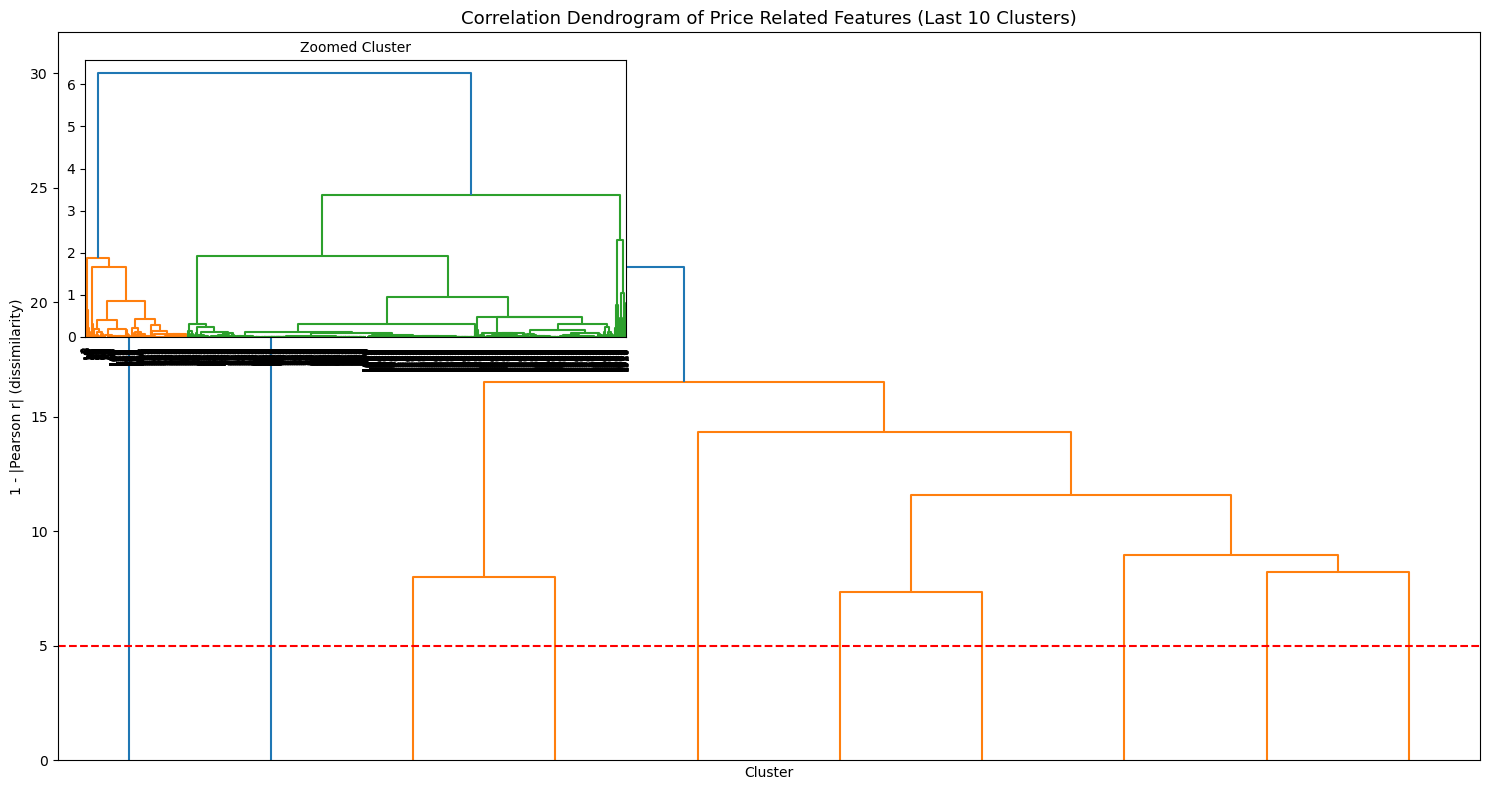

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

# Get exact displayed nodes from the truncated dendrogram
ddata = dendrogram(
    Z,
    truncate_mode="lastp",
    p=10,
    no_plot=True
)

shown_nodes = ddata["leaves"]

# Map actual dendrogram node ids -> your semantic labels
node_label_map = {
    node: cluster_label_map[i]
    for i, node in enumerate(shown_nodes, start=1)
}

def label_func(node_id):
    return node_label_map.get(node_id, str(node_id))


fig, ax = plt.subplots(figsize=(15, 8))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=10,
    labels=prices.columns,
    ax=ax
)

ax.set_title(
    "Correlation Dendrogram of Price Related Features (Last 10 Clusters)",
    fontsize=13
)
ax.set_xlabel("Cluster")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
ax.axhline(y=5, color="red", linestyle="--")


# -----------------------------
# Inset dendrogram
# -----------------------------
zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = 1 - zoom_corr

Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

axins = inset_axes(
    ax,
    width="38%",
    height="38%",
    loc="upper left",
    borderpad=2
)

dendrogram(
    Z_zoom,
    leaf_label_func=label_func,
    ax=axins,
    leaf_rotation=90,
    leaf_font_size=7
)

axins.set_title("Zoomed Cluster", fontsize=10)
axins.set_xlabel("")
axins.set_ylabel("")

plt.tight_layout()
plt.show()

In [77]:
selected_cluster_id = 10  # whichever of the last 10 clusters you are zooming into
zoom_cols = last10_clusters[selected_cluster_id - 1]["features"]

zoom_label = cluster_label_map[selected_cluster_id]

/var/folders/8t/x329s8055vdgtxtnhtz6vkzr0000gn/T/ipykernel_60908/2268393515.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


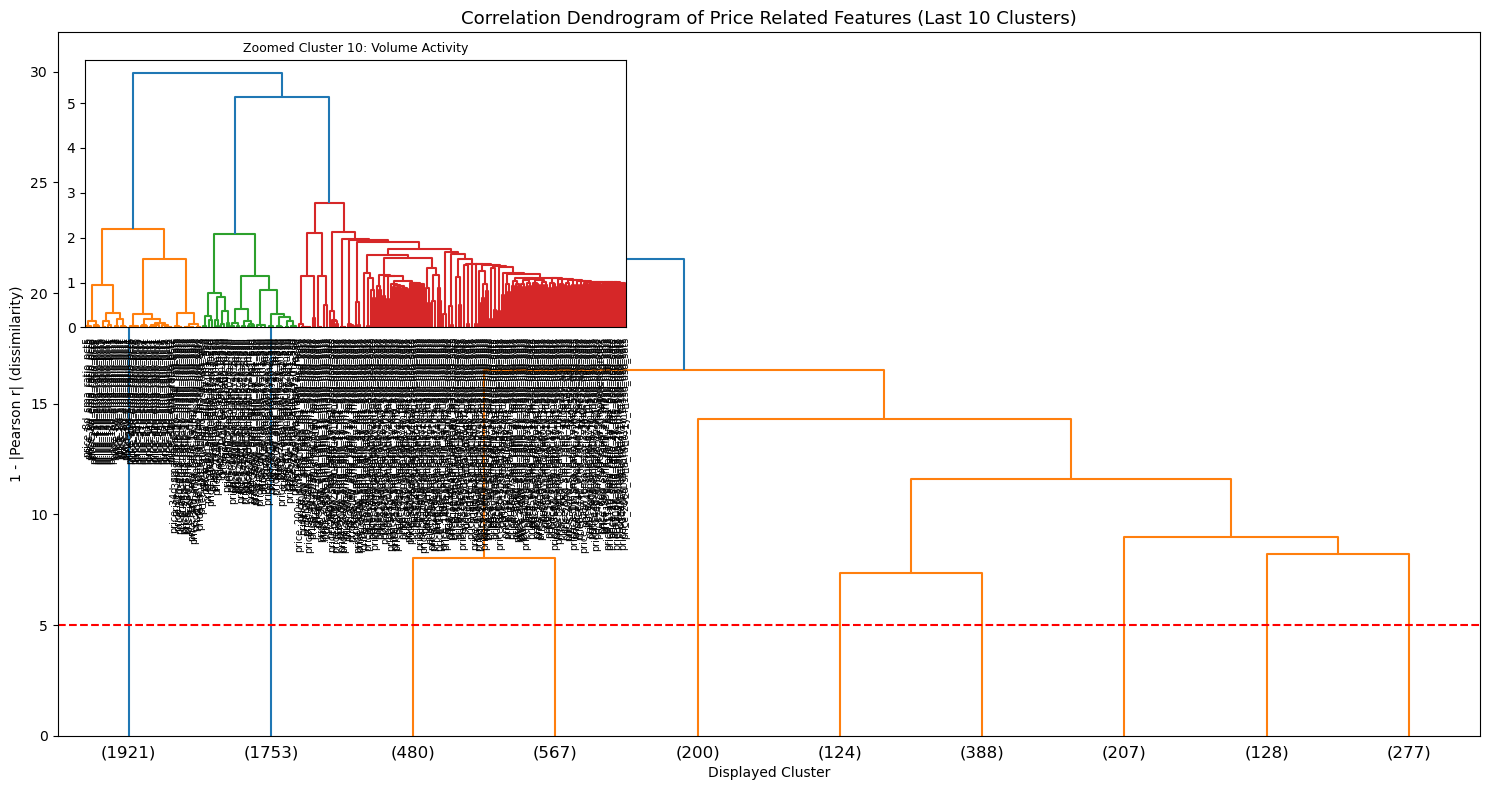

In [78]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(15, 8))

# Main dendrogram: keep numeric cluster labels
dendrogram(
    Z,
    truncate_mode="lastp",
    p=10,
    show_leaf_counts=True,
    ax=ax
)

ax.set_title(
    "Correlation Dendrogram of Price Related Features (Last 10 Clusters)",
    fontsize=13
)
ax.set_xlabel("Displayed Cluster")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
ax.axhline(y=5, color="red", linestyle="--")


# Inset dendrogram for selected cluster
zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = 1 - zoom_corr
Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

axins = inset_axes(
    ax,
    width="38%",
    height="38%",
    loc="upper left",
    borderpad=2
)

dendrogram(
    Z_zoom,
    labels=zoom_cols,
    ax=axins,
    leaf_rotation=90,
    leaf_font_size=7
)

axins.set_title(
    f"Zoomed Cluster {selected_cluster_id}: {zoom_label}",
    fontsize=9
)
axins.set_xlabel("")
axins.set_ylabel("")

plt.tight_layout()
plt.show()

In [79]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def clean_label(col):
    col = col.lower()
    col = re.sub(r"[_\W]+", " ", col)
    return col

def make_short_label(col, max_words=3):
    tokens = clean_label(col).split()

    stopwords = {
        "price", "usd", "sats", "value", "count", "ratio",
        "mean", "median", "sum", "total", "index"
    }

    tokens = [t for t in tokens if t not in stopwords]

    if len(tokens) == 0:
        return col

    return " ".join(tokens[:max_words])

In [80]:
zoom_cols = last10_clusters[selected_cluster_id - 1]["features"]

short_zoom_labels = [make_short_label(c) for c in zoom_cols]

In [82]:
short_zoom_labels

['8d sma pct5',
 '1w sma pct5',
 '1w ema pct5',
 '8d ema pct5',
 '21d sma pct5',
 '13d sma pct5',
 '12d ema pct5',
 '13d ema pct5',
 '13d sma pct2',
 '12d ema pct2',
 '13d ema pct2',
 '13d sma pct1',
 '12d ema pct1',
 '13d ema pct1',
 '1w ema pct2',
 '8d ema pct2',
 '1w sma pct2',
 '8d sma pct2',
 '1w sma pct1',
 '8d ema pct1',
 '1w ema pct1',
 '8d sma pct1',
 '21d ema pct5',
 '26d ema pct5',
 '1m ema pct5',
 '34d ema pct5',
 '1m sma pct5',
 '34d sma pct5',
 '21d ema pct2',
 '21d sma pct2',
 '21d ema pct1',
 '21d sma pct1',
 '1m sma pct1',
 '34d sma pct1',
 '26d ema pct1',
 '1m ema pct1',
 '34d ema pct1',
 '55d sma pct1',
 '55d sma pct2',
 '55d sma pct5',
 '1m sma pct2',
 '34d sma pct2',
 '26d ema pct2',
 '1m ema pct2',
 '34d ema pct2',
 '34d sma 4y',
 '34d sma m3sd',
 '1m ema 1y',
 '34d ema 4y',
 '34d ema m3sd',
 '26d ema 1y',
 '21d sma 1y',
 '26d ema 4y',
 '26d ema m3sd',
 '1m sma 1y',
 '34d sma 1y',
 '1m ema 4y',
 '1m ema m3sd',
 '1m sma 4y',
 '1m sma m3sd',
 '2y ema 4y',
 '1y sma 4

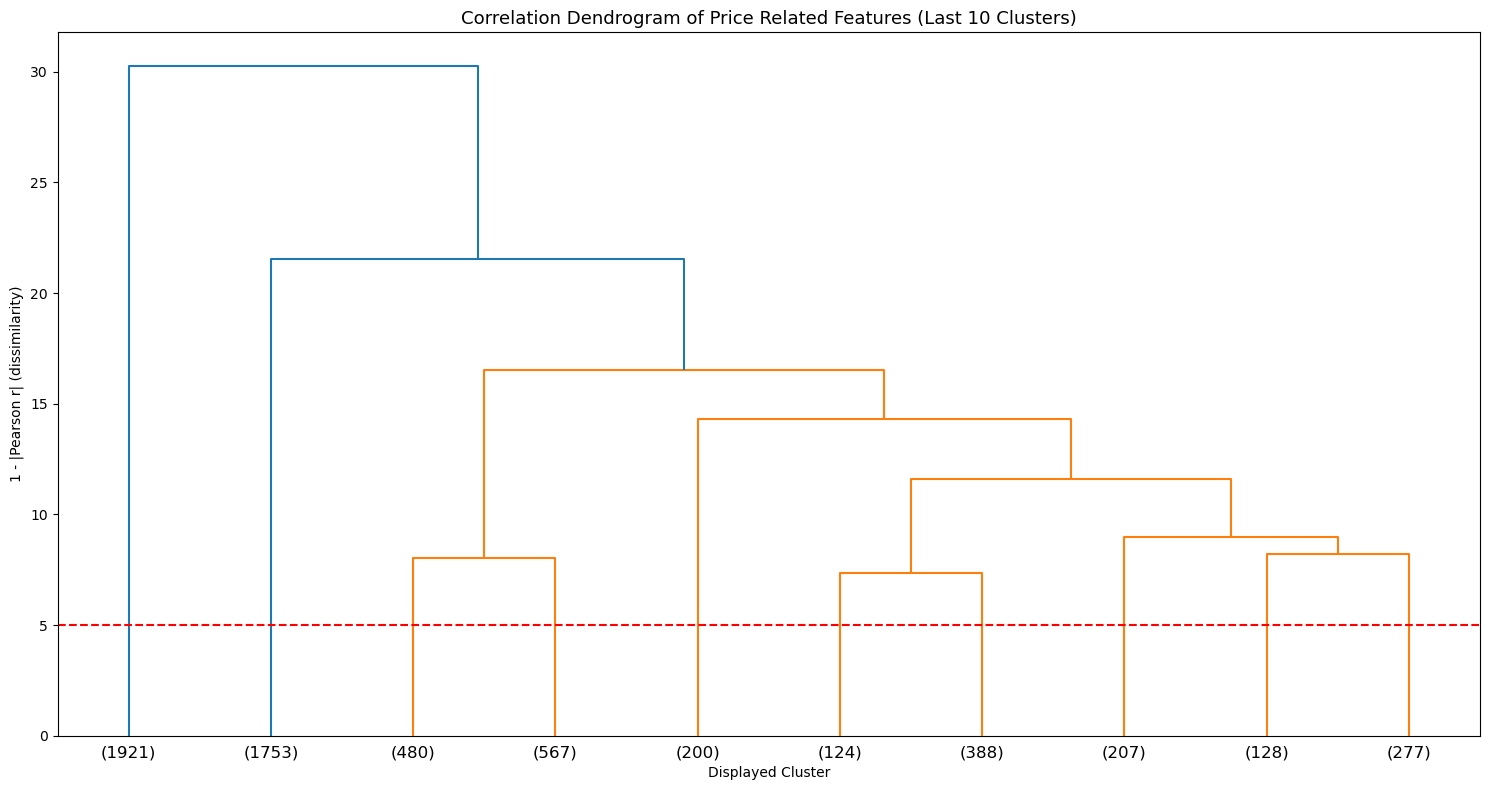

In [81]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(15, 8))

# Main dendrogram: keep numeric cluster labels
dendrogram(
    Z,
    truncate_mode="lastp",
    p=10,
    show_leaf_counts=True,
    ax=ax
)

ax.set_title(
    "Correlation Dendrogram of Price Related Features (Last 10 Clusters)",
    fontsize=13
)
ax.set_xlabel("Displayed Cluster")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
ax.axhline(y=5, color="red", linestyle="--")


zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = 1 - zoom_corr
Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

short_zoom_labels = [make_short_label(c) for c in zoom_cols]

dendrogram(
    Z_zoom,
    labels=short_zoom_labels,
    ax=axins,
    leaf_rotation=90,
    leaf_font_size=7
)

axins.set_title(
    f"Zoomed Cluster {selected_cluster_id}: {cluster_label_map[selected_cluster_id]}",
    fontsize=9
)
axins.set_xlabel("")
axins.set_ylabel("")

plt.tight_layout()
plt.show()

In [83]:
from scipy.cluster.hierarchy import dendrogram
from collections import Counter
import re

def get_cluster_members(node_id, Z_local, labels):
    n = len(labels)

    if node_id < n:
        return [labels[node_id]]

    row = int(node_id - n)
    left = int(Z_local[row, 0])
    right = int(Z_local[row, 1])

    return (
        get_cluster_members(left, Z_local, labels)
        + get_cluster_members(right, Z_local, labels)
    )


def make_topic_label(cols, top_n=3):
    stopwords = {
        "price", "usd", "sats", "count", "value", "ratio",
        "mean", "median", "sum", "total", "index",
        "open", "high", "low", "close"
    }

    tokens = []

    for col in cols:
        parts = re.split(r"[_\W]+", col.lower())
        tokens.extend([p for p in parts if p and p not in stopwords])

    counts = Counter(tokens)

    top_terms = [term for term, _ in counts.most_common(top_n)]

    if len(top_terms) == 0:
        return f"{len(cols)} features"

    return " / ".join(top_terms)

In [84]:
# Get the actual displayed nodes in the truncated inset dendrogram
inset_ddata = dendrogram(
    Z_zoom,
    truncate_mode="lastp",
    p=10,
    no_plot=True
)

inset_nodes = inset_ddata["leaves"]

# Build semantic labels for the displayed inset nodes
inset_node_label_map = {}

for node in inset_nodes:
    members = get_cluster_members(node, Z_zoom, zoom_cols)
    label = make_topic_label(members)

    # optional: include number of features
    inset_node_label_map[node] = f"{label}\n({len(members)})"


def inset_label_func(node_id):
    return inset_node_label_map.get(node_id, str(node_id))

In [ ]:
zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = 1 - zoom_corr

Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

inset_ddata = dendrogram(
    Z_zoom,
    truncate_mode="lastp",
    p=10,
    no_plot=True
)

inset_nodes = inset_ddata["leaves"]

inset_node_label_map = {}

for node in inset_nodes:
    members = get_cluster_members(node, Z_zoom, zoom_cols)
    label = make_topic_label(members)
    inset_node_label_map[node] = f"{label}\n({len(members)})"


def inset_label_func(node_id):
    return inset_node_label_map.get(node_id, str(node_id))


dendrogram(
    Z_zoom,
    truncate_mode="lastp",
    p=10,
    leaf_label_func=inset_label_func,
    ax=axins,
    leaf_rotation=45,
    leaf_font_size=7
)

axins.set_title(
    f"Zoomed Cluster {selected_cluster_id}: {cluster_label_map[selected_cluster_id]}",
    fontsize=9
)

/var/folders/8t/x329s8055vdgtxtnhtz6vkzr0000gn/T/ipykernel_60908/3903706588.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


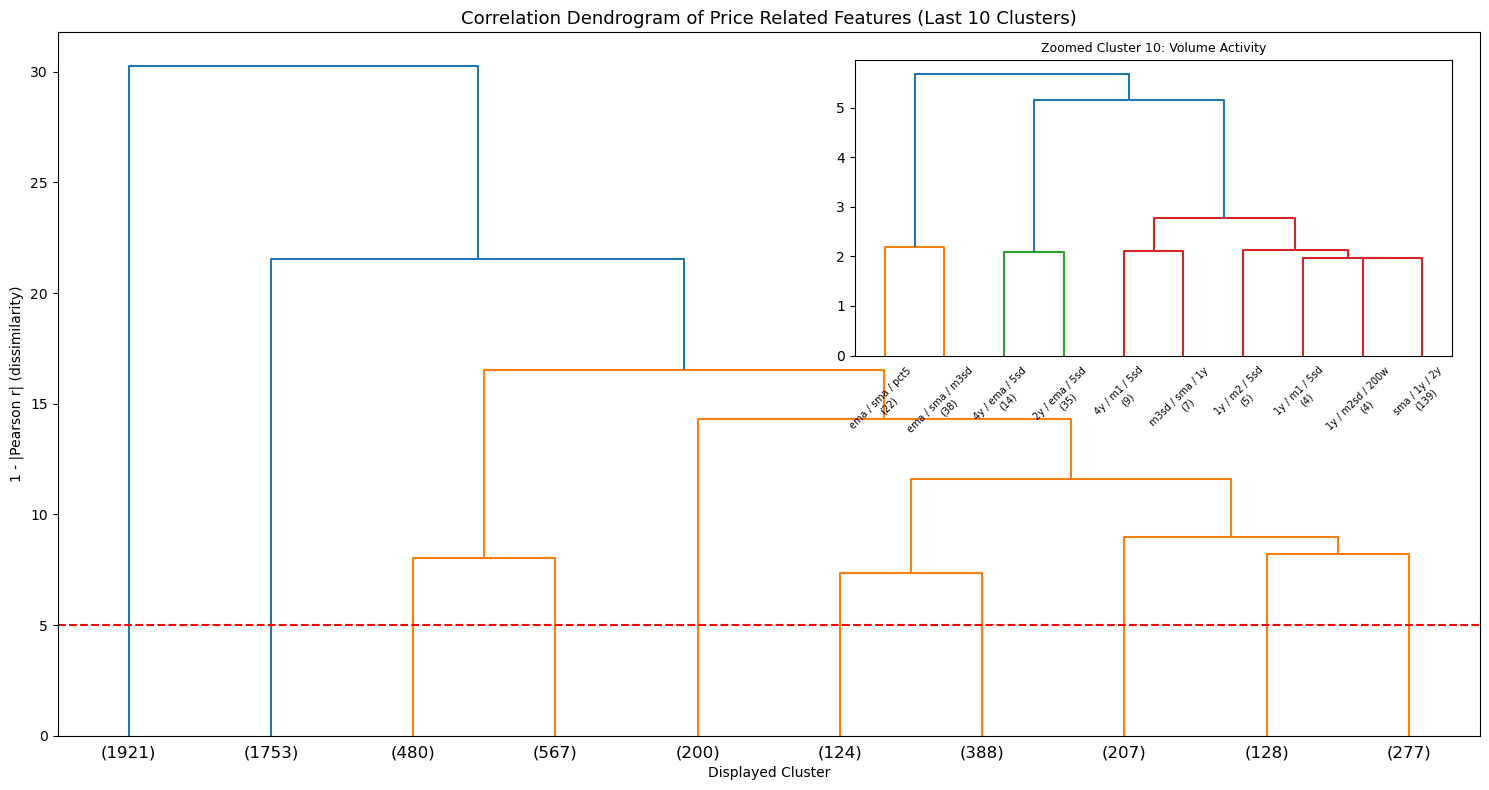

In [87]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(15, 8))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=10,
    show_leaf_counts=True,
    ax=ax
)

ax.set_title(
    "Correlation Dendrogram of Price Related Features (Last 10 Clusters)",
    fontsize=13
)
ax.set_xlabel("Displayed Cluster")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
ax.axhline(y=5, color="red", linestyle="--")


zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = 1 - zoom_corr
Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

inset_ddata = dendrogram(
    Z_zoom,
    truncate_mode="lastp",
    p=10,
    no_plot=True
)

inset_nodes = inset_ddata["leaves"]

inset_node_label_map = {}

for node in inset_nodes:
    members = get_cluster_members(node, Z_zoom, zoom_cols)
    label = make_topic_label(members)
    inset_node_label_map[node] = f"{label}\n({len(members)})"

def inset_label_func(node_id):
    return inset_node_label_map.get(node_id, str(node_id))


# CREATE THE INSET AXIS
axins = inset_axes(
    ax,
    width="42%",
    height="42%",
    loc="upper right",
    borderpad=2
)

dendrogram(
    Z_zoom,
    truncate_mode="lastp",
    p=10,
    leaf_label_func=inset_label_func,
    ax=axins,
    leaf_rotation=45,
    leaf_font_size=7
)

axins.set_title(
    f"Zoomed Cluster {selected_cluster_id}: {cluster_label_map[selected_cluster_id]}",
    fontsize=9
)
axins.set_xlabel("")
axins.set_ylabel("")

plt.tight_layout()
plt.show()

In [88]:
fig.savefig(ROOT / "docs" / "figures" / "price_dendrogram_new.png", dpi=300)

In [51]:
fig.savefig(ROOT / "docs" / "figures" / "price_dendrogram_new.png", dpi=300)

/var/folders/8t/x329s8055vdgtxtnhtz6vkzr0000gn/T/ipykernel_60908/725092261.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


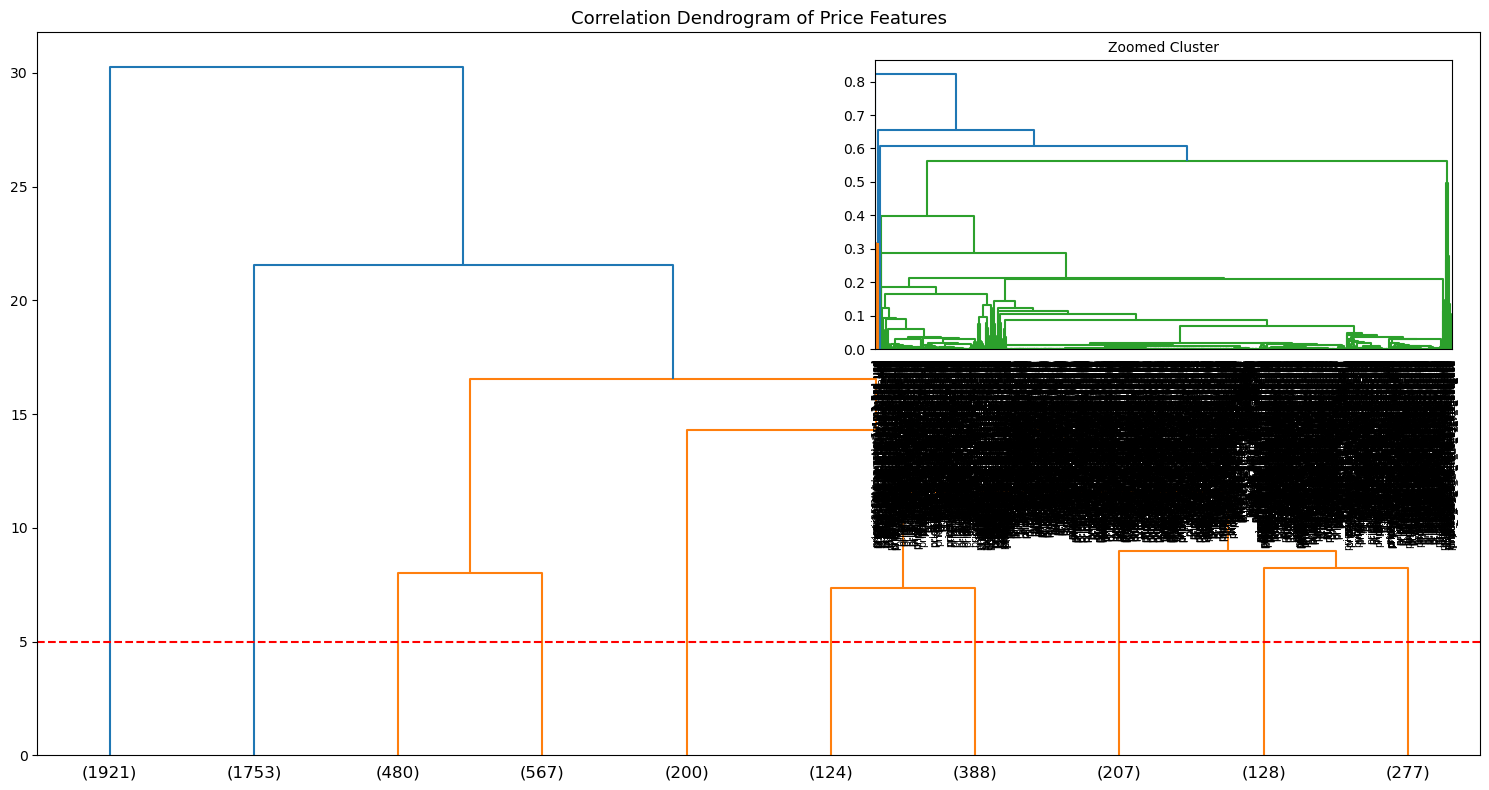

In [61]:
fig, ax = plt.subplots(figsize=(15, 8))

# ---------------- MAIN ----------------
dendrogram(
    Z,
    truncate_mode='lastp',
    p=10,
    labels=prices.columns,
    ax=ax
)

ax.set_title(
    "Correlation Dendrogram of Price Features",
    fontsize=13
)

ax.axhline(y=5, color="red", linestyle="--")


# ---------------- SELECT CLUSTER ----------------
zoom_cols = last10_clusters[0]["features"]


# ---------------- BUILD INSET ----------------
zoom_corr = prices[zoom_cols].corr().abs()

zoom_dist = 1 - zoom_corr

Z_zoom = linkage(
    squareform(zoom_dist, checks=False),
    method="average"
)

axins = inset_axes(
    ax,
    width="40%",
    height="40%",
    loc="upper right",
    borderpad=2
)

dendrogram(
    Z_zoom,
    labels=zoom_cols,
    ax=axins,
    leaf_rotation=90,
    leaf_font_size=7
)

axins.set_title(
    "Zoomed Cluster",
    fontsize=10
)

plt.tight_layout()
plt.show()